### Building Chatbot with Multiple Tools using LangGraph

#### Aim

Create a chatbot with tool capabilities from:
- Arxiv
- Wikipedia
- Tavily Search

In [65]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage
import os
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get('tavily_api_key'):
    os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

In [56]:
# Arxiv
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,load_max_docs=1, doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [57]:
# Wikipedia
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

In [58]:
# Tavily Search
tavily_tool = TavilySearchResults(max_results=5, topic='general')

In [59]:
 # Combine all tools
 tools = [arxiv_tool, wiki_tool, tavily_tool]

In [60]:
# Initialize the LLM
from langchain_groq import ChatGroq

llm = ChatGroq(model='openai/gpt-oss-120b')
llm_with_tools = llm.bind_tools(tools)

In [61]:
# State Schema
from typing import TypedDict, Annotated
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

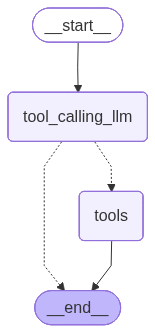

In [64]:
# Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

# Build Graph
builder = StateGraph(State)

# Node
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools=tools))

# Edge
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tool_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tool_condition routes to END
    tools_condition
)
builder.add_edge('tools', END)

# Compile
graph = builder.compile()

# Display
display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
messages = graph.invoke({'messages': HumanMessage(content='1706.03762')})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_7b6fd881-069d-4378-9468-85e2b52762c7)
 Call ID: fc_7b6fd881-069d-4378-9468-85e2b52762c7
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [70]:
messages = graph.invoke({'messages': HumanMessage(content='what is the weather in ooty 30th March 2026 12 AM?')})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is the weather in ooty 30th March 2026 12 AM?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_a5f92082-88b5-40a5-9fcf-141ff4b0c213)
 Call ID: fc_a5f92082-88b5-40a5-9fcf-141ff4b0c213
  Args:
    query: Ooty weather March 30 2026 forecast
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Ooty weather in March 2026 | Ooty 14 day weather - Weather25.com", "url": "https://www.weather25.com/asia/india/tamil-nadu/ooty?page=month&month=March", "content": "weather25.com\nSearch\nweather in India\nRemove from your favorite locations\nAdd to my locations\nShare\nweather in India\n\n# Ooty weather in March 2026\n\nPatchy rain possible\nPatchy rain possible\nPatchy rain possible\nPatchy rain possible\nPatchy rain possible\nPatchy rain possible\nLight rain showe

In [72]:
messages = graph.invoke({'messages': HumanMessage(content='what is machine learning?')})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is machine learning?
================================== Ai Message ==================================

**Machine learning (ML)** is a subfield of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn patterns from data** and make decisions or predictions without being explicitly programmed for each specific task.

### Core Idea
- **Learning from data:** An ML system is given examples (training data) consisting of inputs (e.g., images, text, sensor readings) and often corresponding outputs (labels, targets, or rewards).  
- **Model building:** The algorithm builds a mathematical model that captures relationships in the data.  
- **Generalization:** Once trained, the model can apply what it has learned to new, unseen data, performing tasks such as classification, regression, clustering, or control.

### Main Types of Machine Learning
